# Telemetria GPU

Análise dos dados de telemetria coletados durante os experimentos de inferência a partir do `nvidia-smi` em cada nó.

## Setup

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


PROCESSED_DIR = Path('../data_processed')
FIGURES_DIR = Path('../figures/gpu_telemetry')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_PATH = PROCESSED_DIR / 'gpu_timeseries.csv'

ts_df = pd.read_csv(TIMESERIES_PATH, parse_dates=['timestamp'])

experiment_names = sorted(ts_df['experiment_name'].unique())

print(f"{len(experiment_names)} experiments in {TIMESERIES_PATH}")
for name in experiment_names:
    print(f"  {name}")

14 experiments in ../data_processed/gpu_timeseries.csv
  N1_tupi_none_long_r1_780636
  N1_tupi_none_short_r1_780637
  N2_poti_PP_long_r1_780630
  N2_poti_PP_short_r1_780628
  N2_poti_TP_long_r1_780629
  N2_poti_TP_short_r1_780627
  N2_tupi_PP_long_r1_781237
  N2_tupi_PP_short_r1_781238
  N2_tupi_TP_long_r1_781236
  N2_tupi_TP_short_r1_781235
  N4_poti_PP_long_r1_780638
  N4_poti_PP_short_r1_780634
  N4_poti_TP_long_r1_780632
  N4_poti_TP_short_r1_780631


### Helpers

Funções auxiliares para formatar nomes de experimentos e métricas nos gráficos

In [2]:
def format_node_name(node):
    """poti1 -> POTI-1, tupi6 -> TUPI-6."""
    match = re.match(r'([a-zA-Z]+)(\d+)', node)
    if match:
        return f"{match.group(1).upper()}-{match.group(2)}"
    return node.upper()


def format_experiment_name(name):
    """N2_poti_TP_long_r1_xxx -> '2 Nodes POTI\\nTensor Parallel (Long)'."""
    if not isinstance(name, str):
        return 'Unknown Experiment'

    parts = name.split('_')
    if len(parts) < 4:
        return name

    n_nodes, system, strategy, length = parts[0], parts[1].upper(), parts[2], parts[3]

    node_text = f"{n_nodes[1:]} Node" if n_nodes == 'N1' else f"{n_nodes[1:]} Nodes"
    strat_map = {'none': 'No Comm', 'PP': 'Pipeline Parallel', 'TP': 'Tensor Parallel'}
    strategy_text = strat_map.get(strategy, strategy)
    len_text = 'Short' if length == 'short' else 'Long'

    return f"{node_text} {system}\n{strategy_text} ({len_text})"


def sort_experiments(name):
    """Ordena por (estratégia, workload, N)."""
    name = name.lower()

    if 'none' in name or 'n1' in name:
        parallel_rank = 0  # Single GPU
    elif '_tp_' in name:
        parallel_rank = 1
    elif '_pp_' in name:
        parallel_rank = 2
    else:
        parallel_rank = 3

    size_rank = 0 if 'short' in name else (1 if 'long' in name else 2)

    if 'n1' in name:
        machine_rank = 0
    elif 'n2' in name:
        machine_rank = 1
    elif 'n4' in name:
        machine_rank = 2
    else:
        machine_rank = 3

    return (parallel_rank, size_rank, machine_rank, name)

## Visão geral por experimento

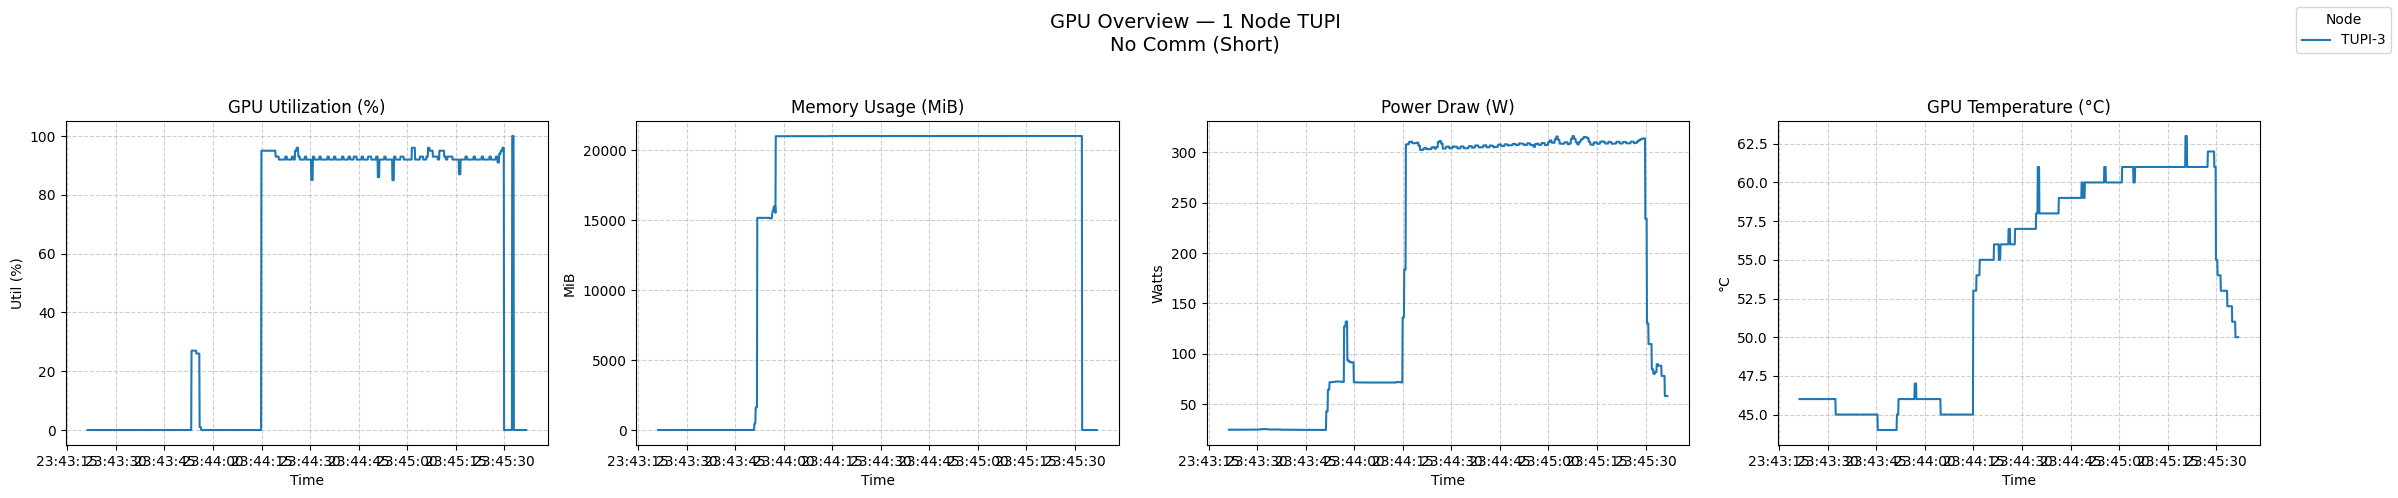

Saved: ../figures/gpu_telemetry/gpu-overview-N1-tupi-none-short-r1-780637.png


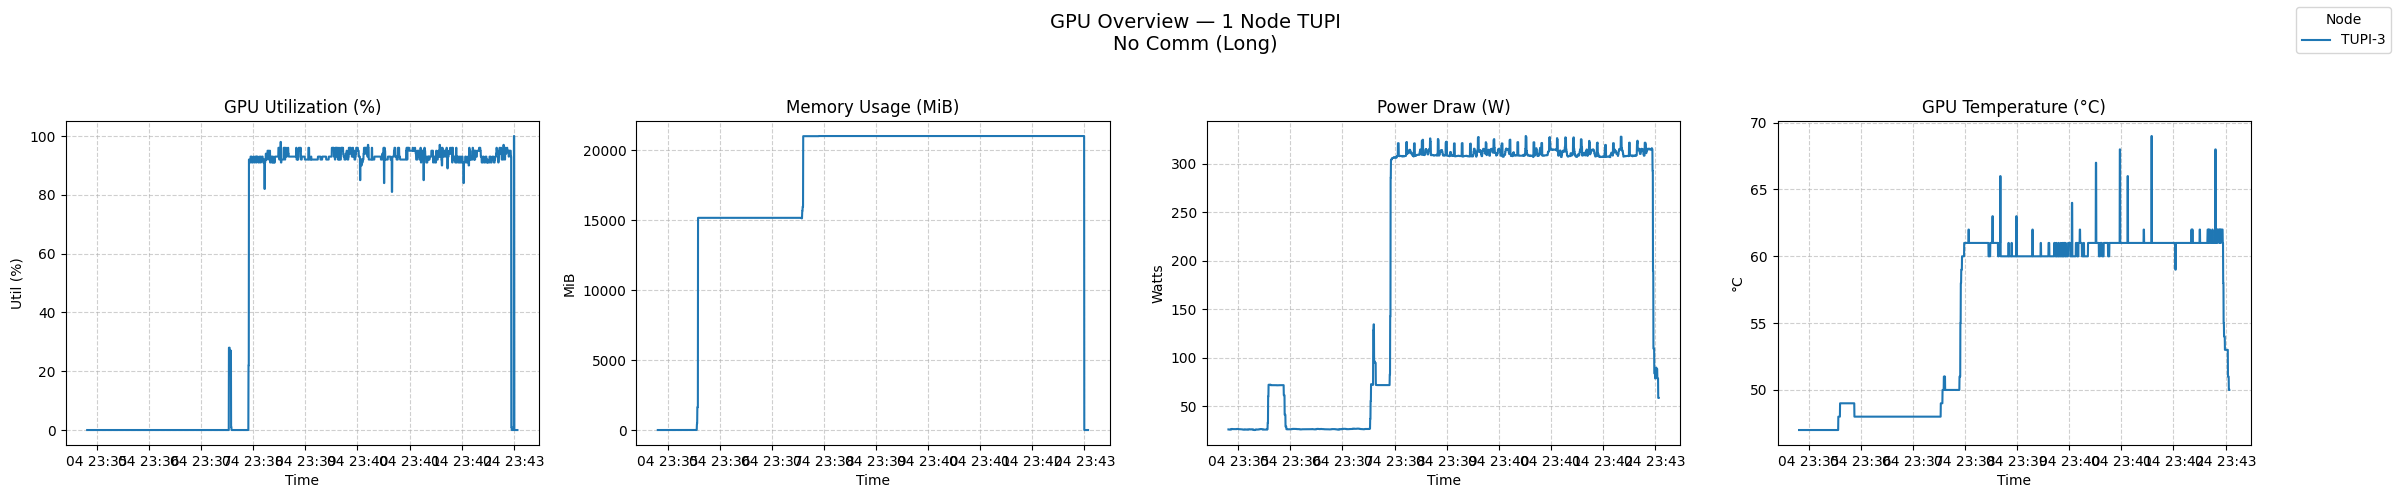

Saved: ../figures/gpu_telemetry/gpu-overview-N1-tupi-none-long-r1-780636.png


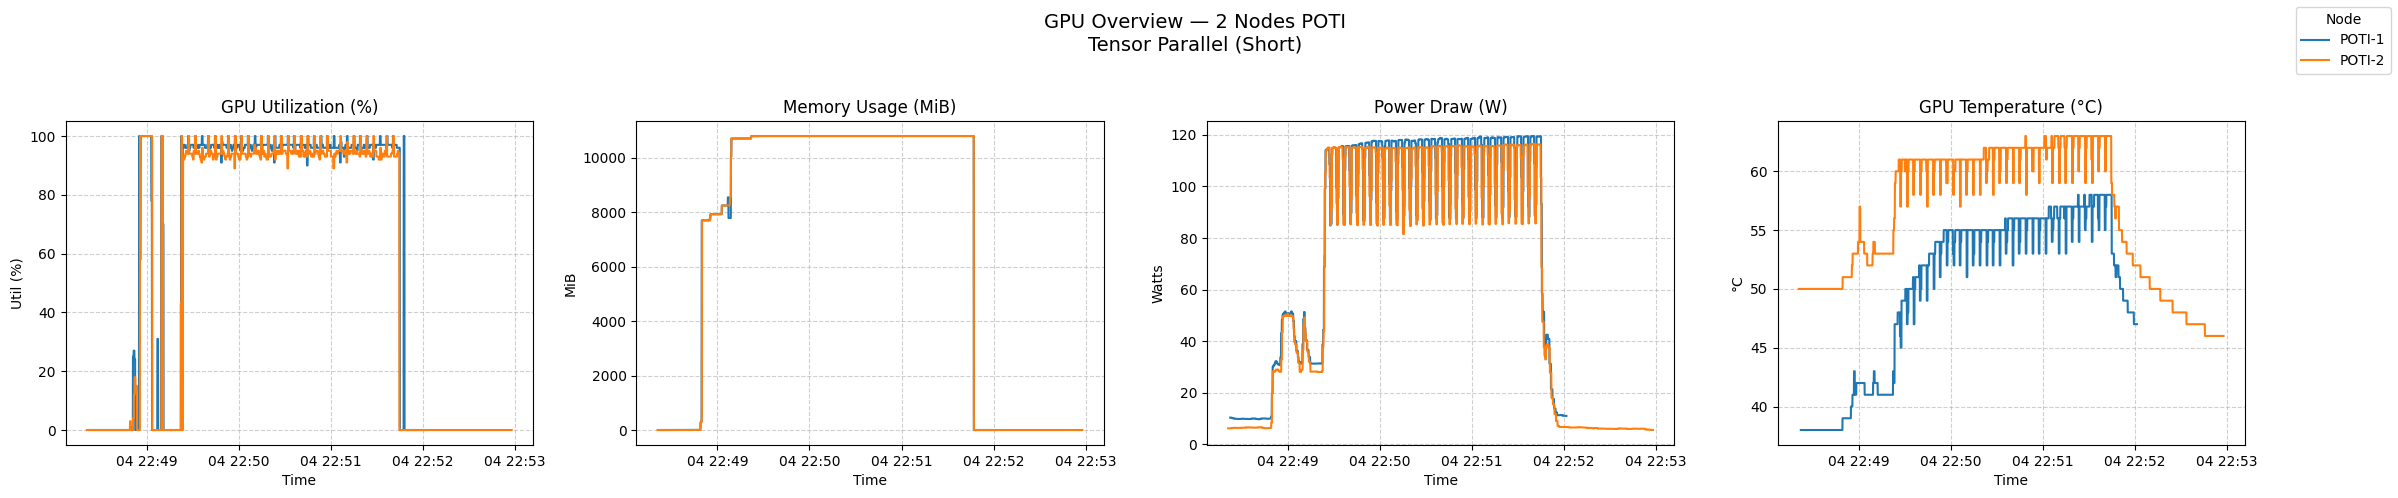

Saved: ../figures/gpu_telemetry/gpu-overview-N2-poti-TP-short-r1-780627.png


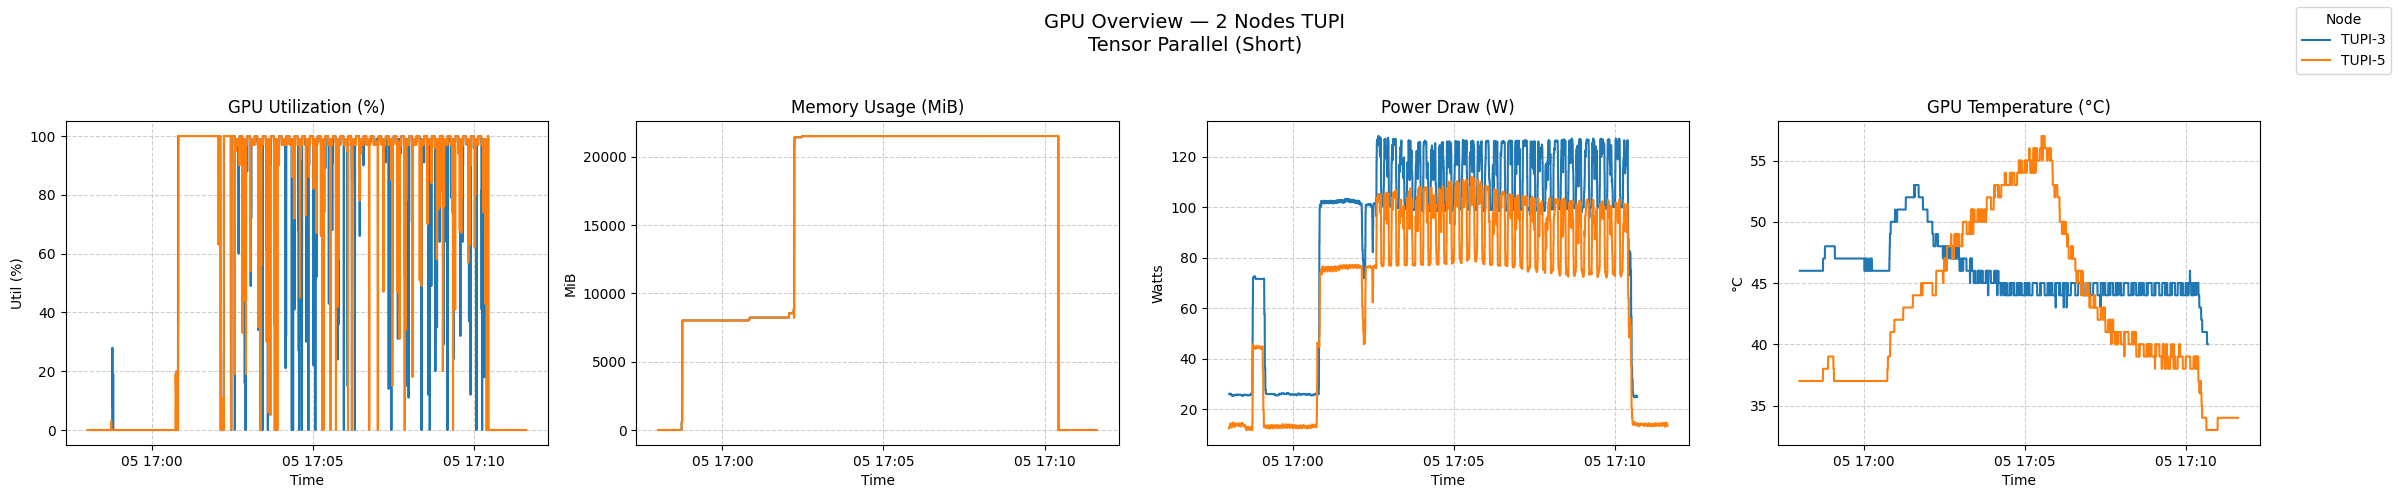

Saved: ../figures/gpu_telemetry/gpu-overview-N2-tupi-TP-short-r1-781235.png


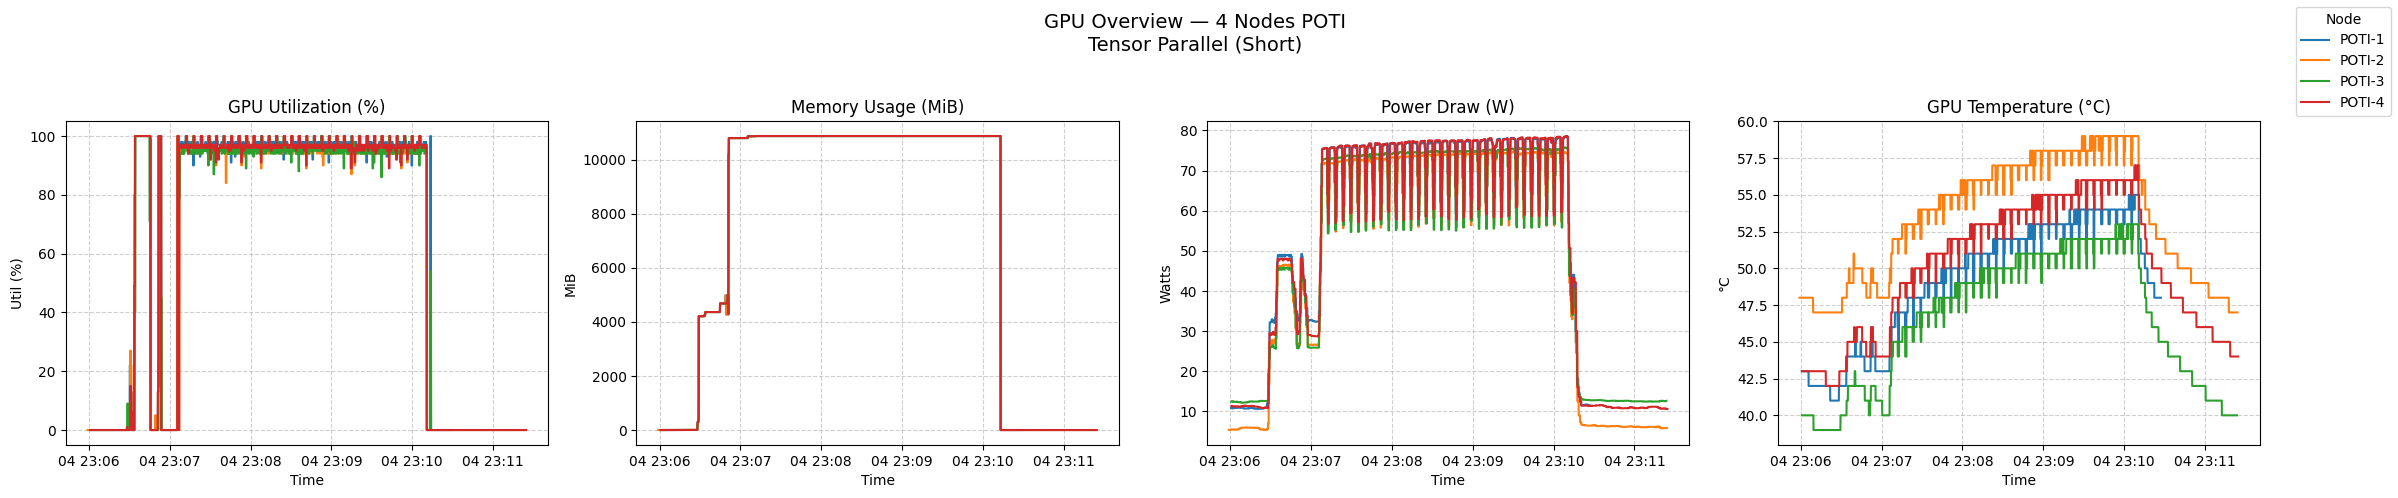

Saved: ../figures/gpu_telemetry/gpu-overview-N4-poti-TP-short-r1-780631.png


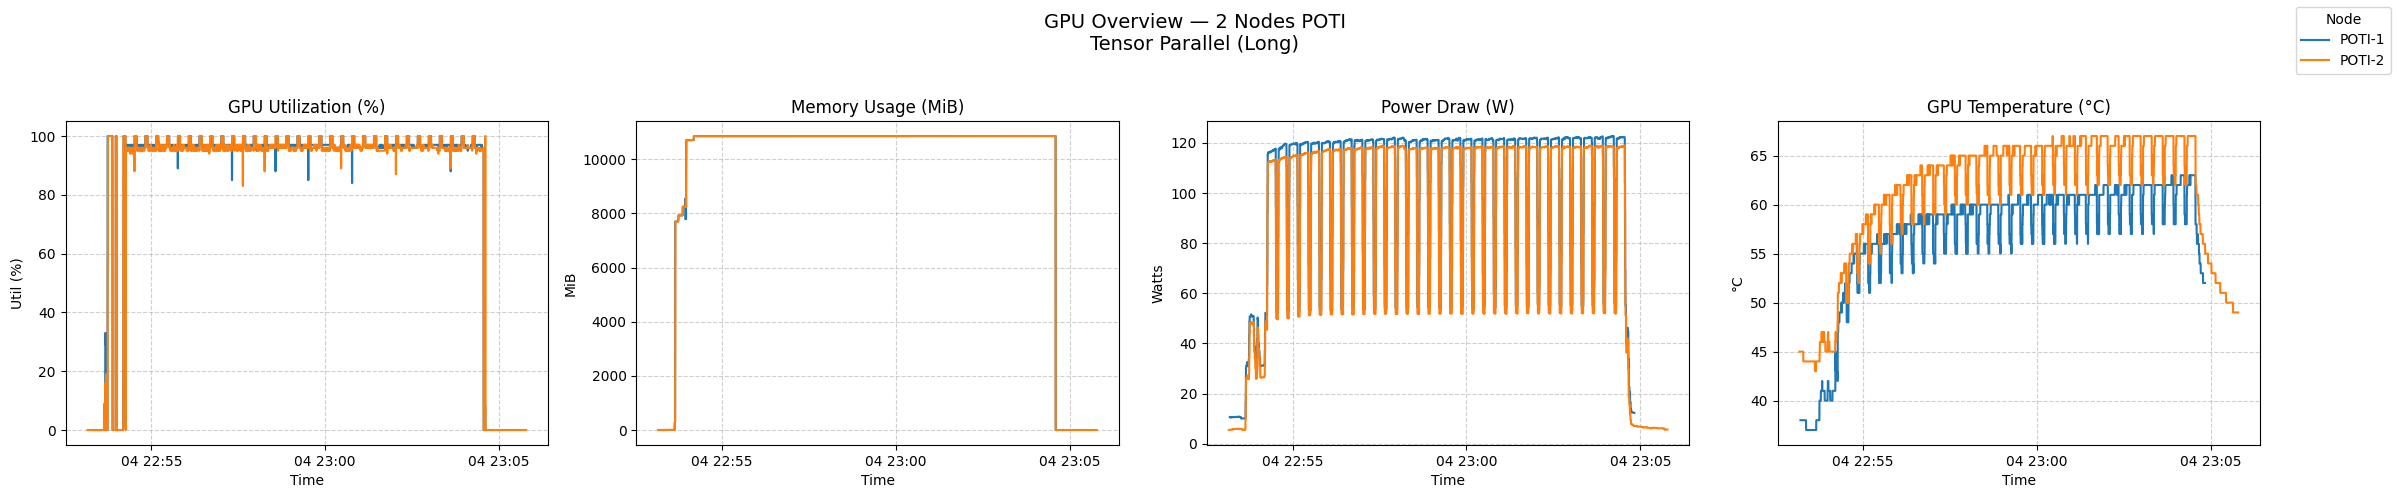

Saved: ../figures/gpu_telemetry/gpu-overview-N2-poti-TP-long-r1-780629.png


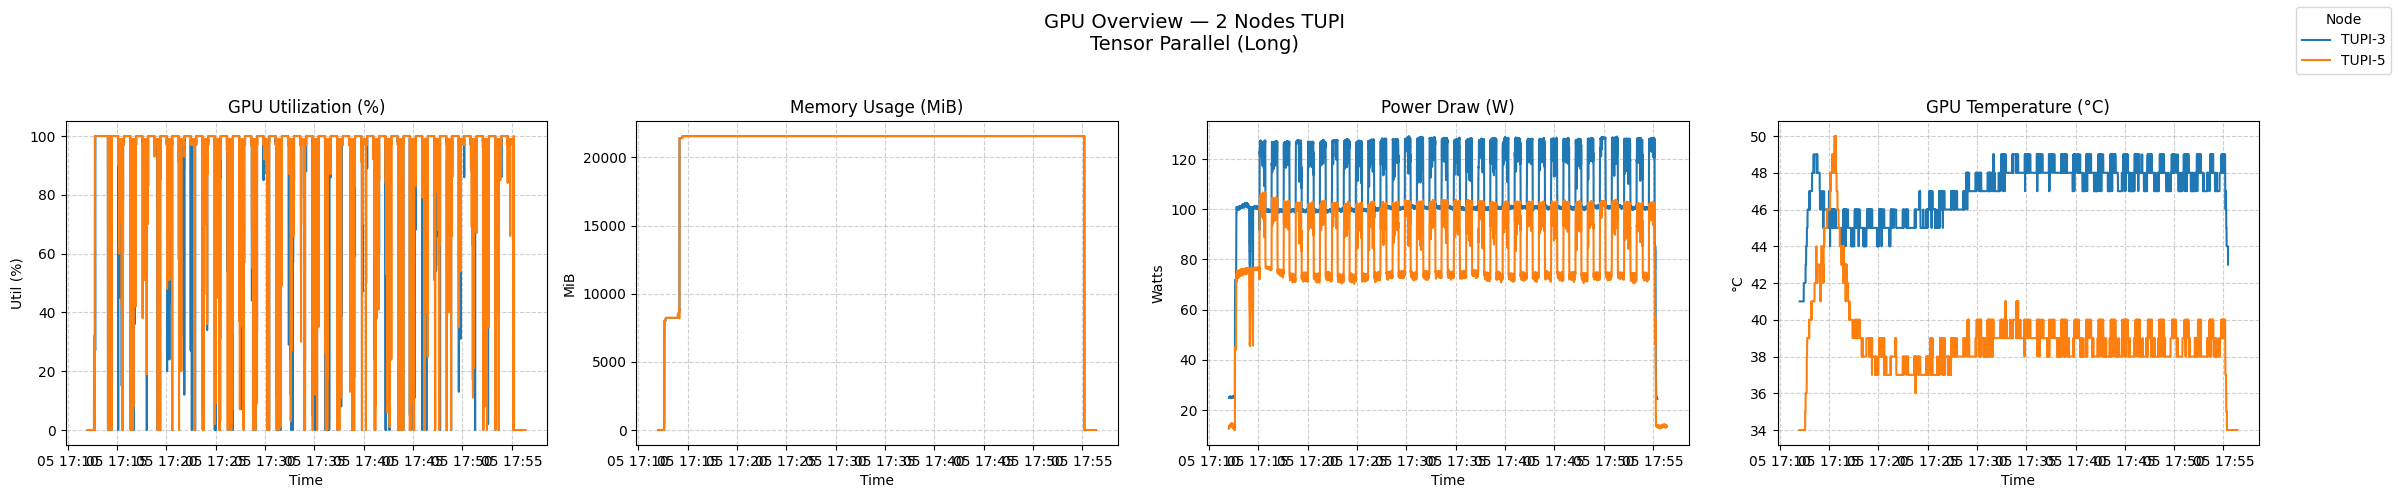

Saved: ../figures/gpu_telemetry/gpu-overview-N2-tupi-TP-long-r1-781236.png


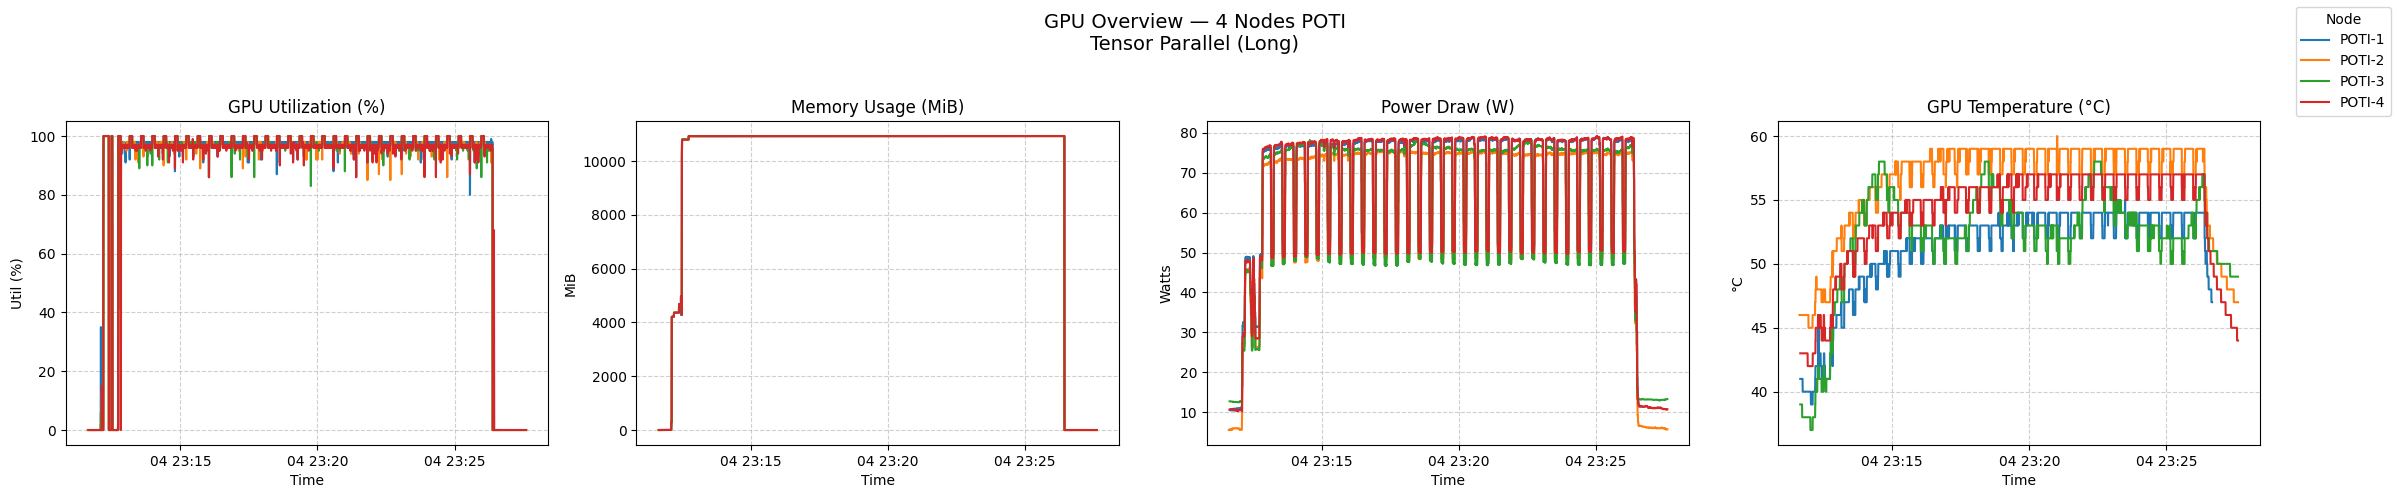

Saved: ../figures/gpu_telemetry/gpu-overview-N4-poti-TP-long-r1-780632.png


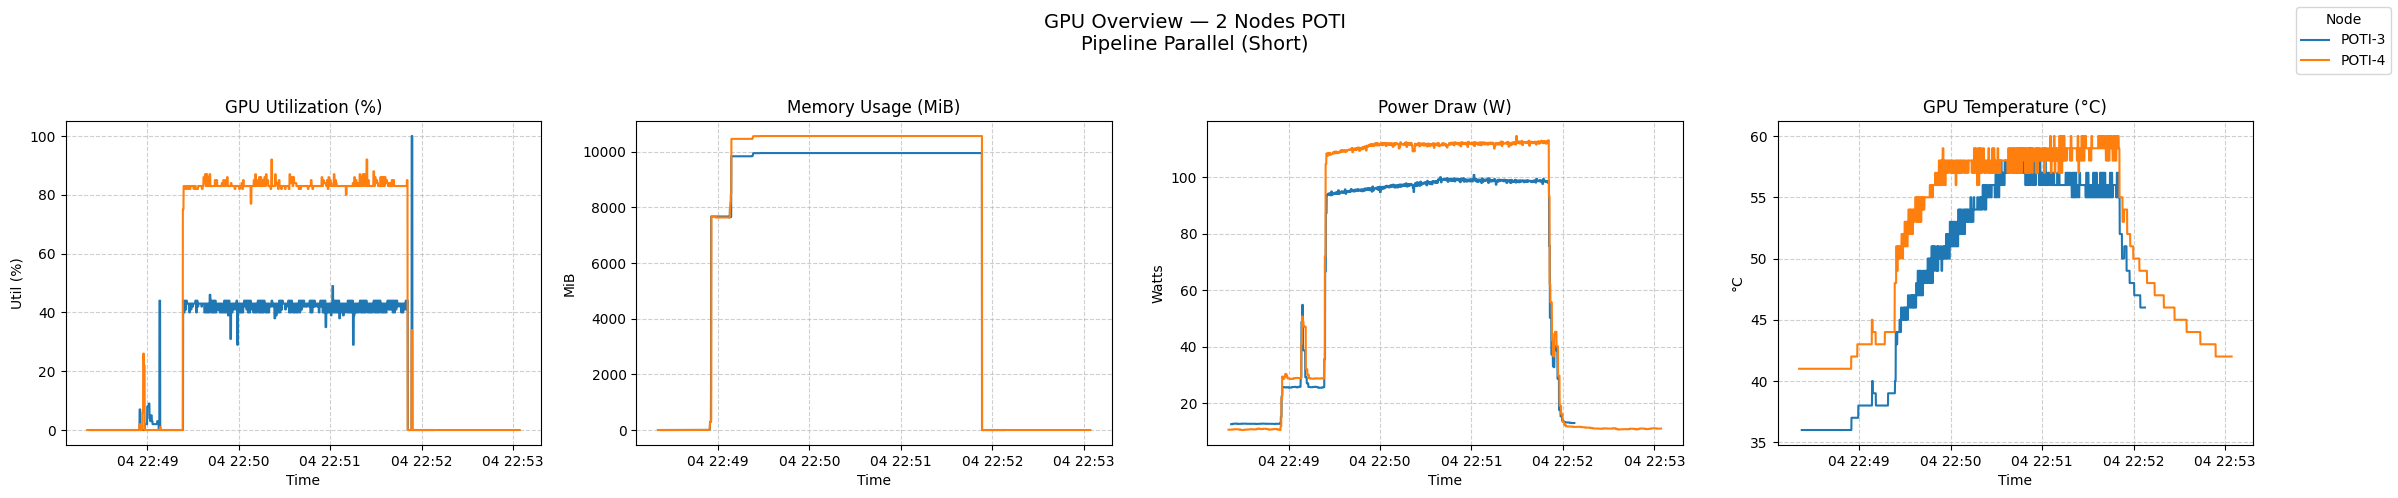

Saved: ../figures/gpu_telemetry/gpu-overview-N2-poti-PP-short-r1-780628.png


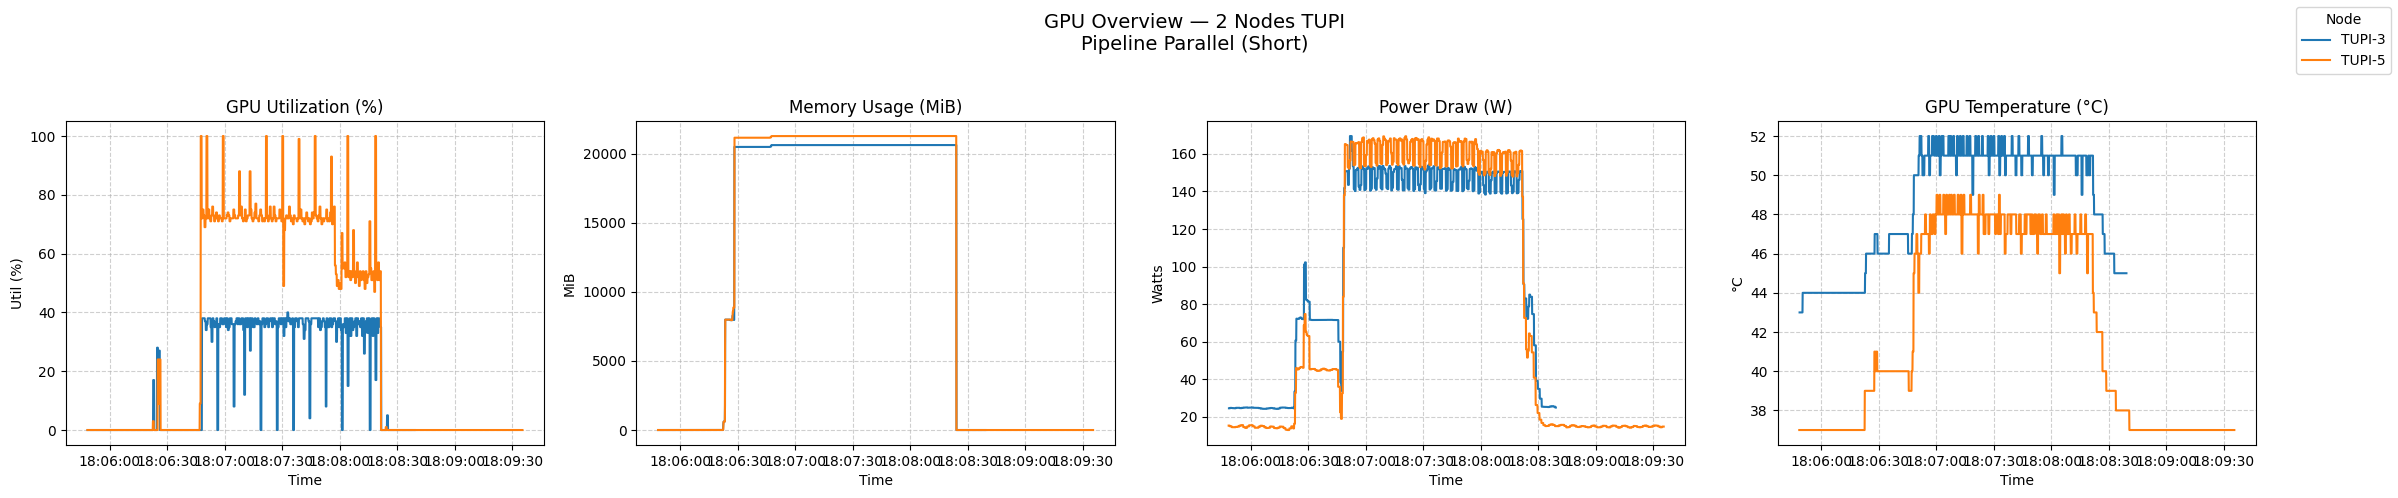

Saved: ../figures/gpu_telemetry/gpu-overview-N2-tupi-PP-short-r1-781238.png


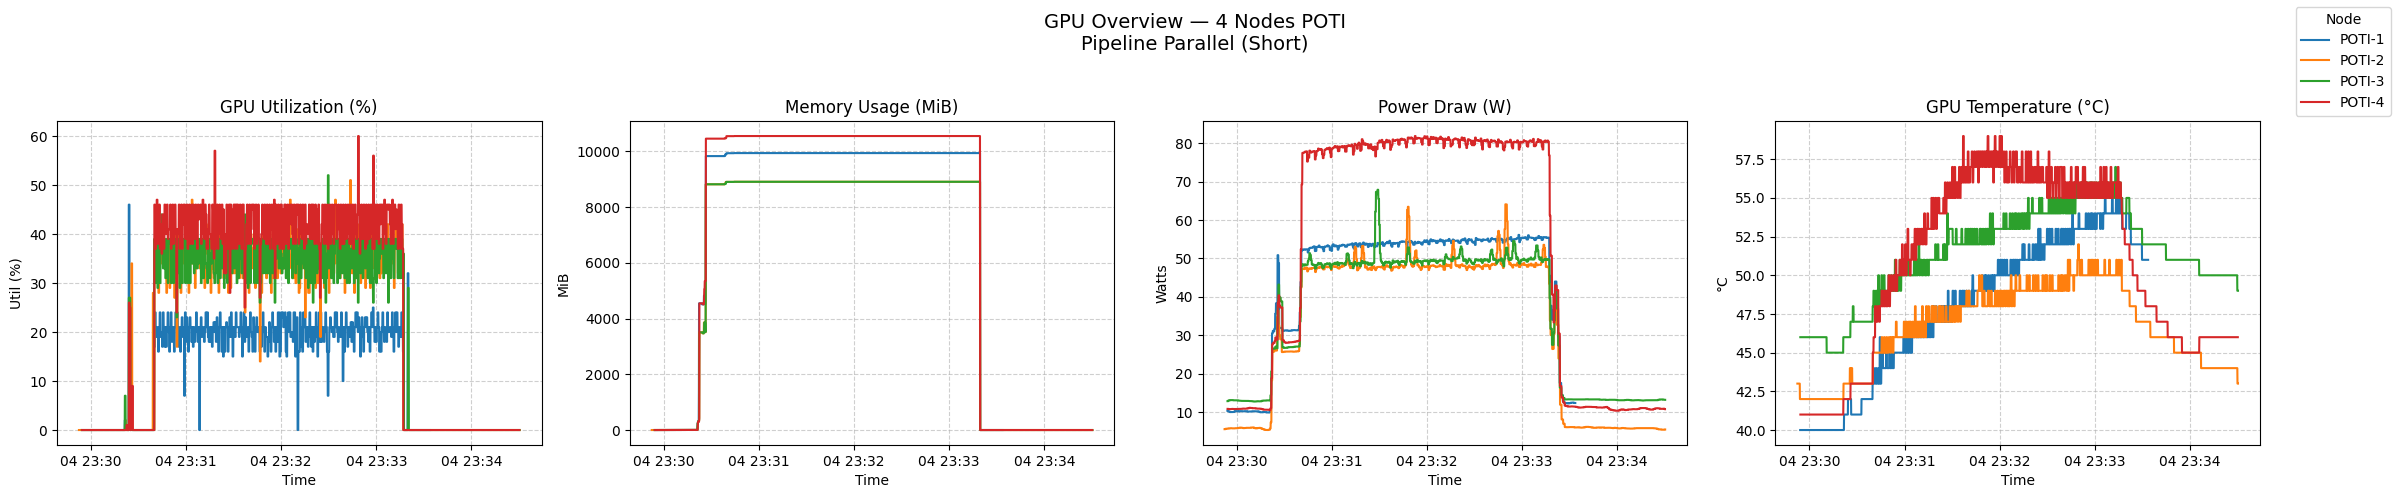

Saved: ../figures/gpu_telemetry/gpu-overview-N4-poti-PP-short-r1-780634.png


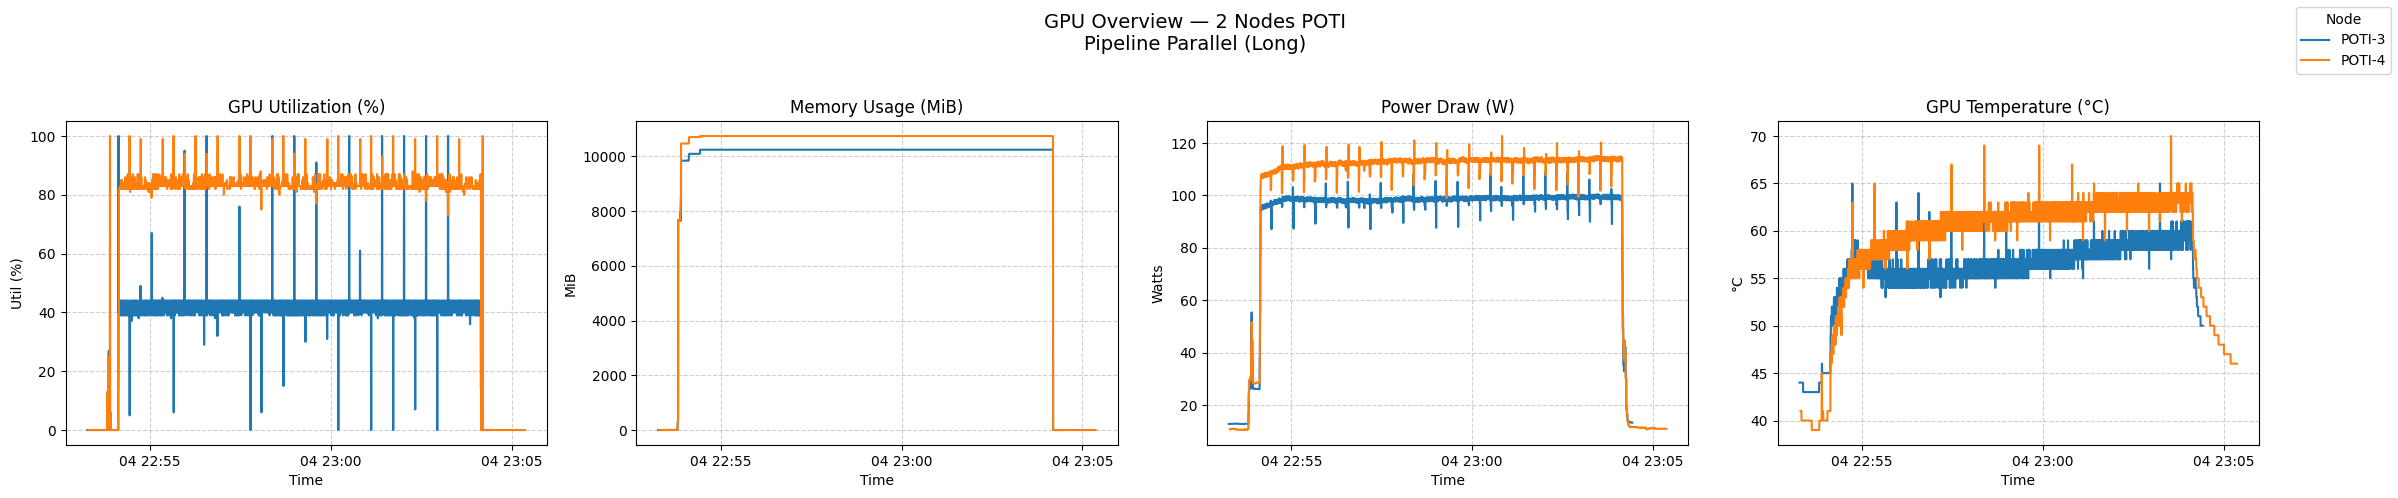

Saved: ../figures/gpu_telemetry/gpu-overview-N2-poti-PP-long-r1-780630.png


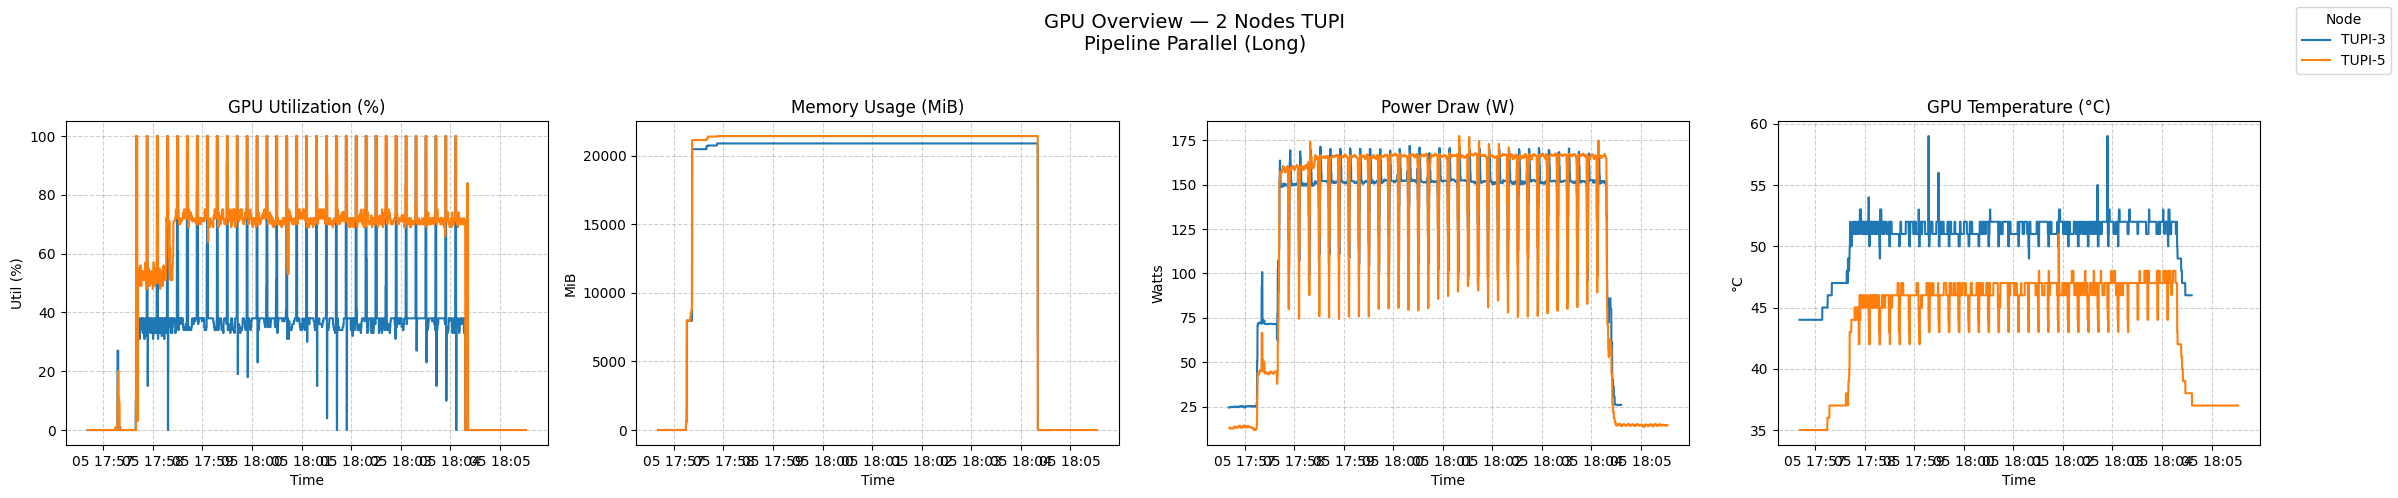

Saved: ../figures/gpu_telemetry/gpu-overview-N2-tupi-PP-long-r1-781237.png


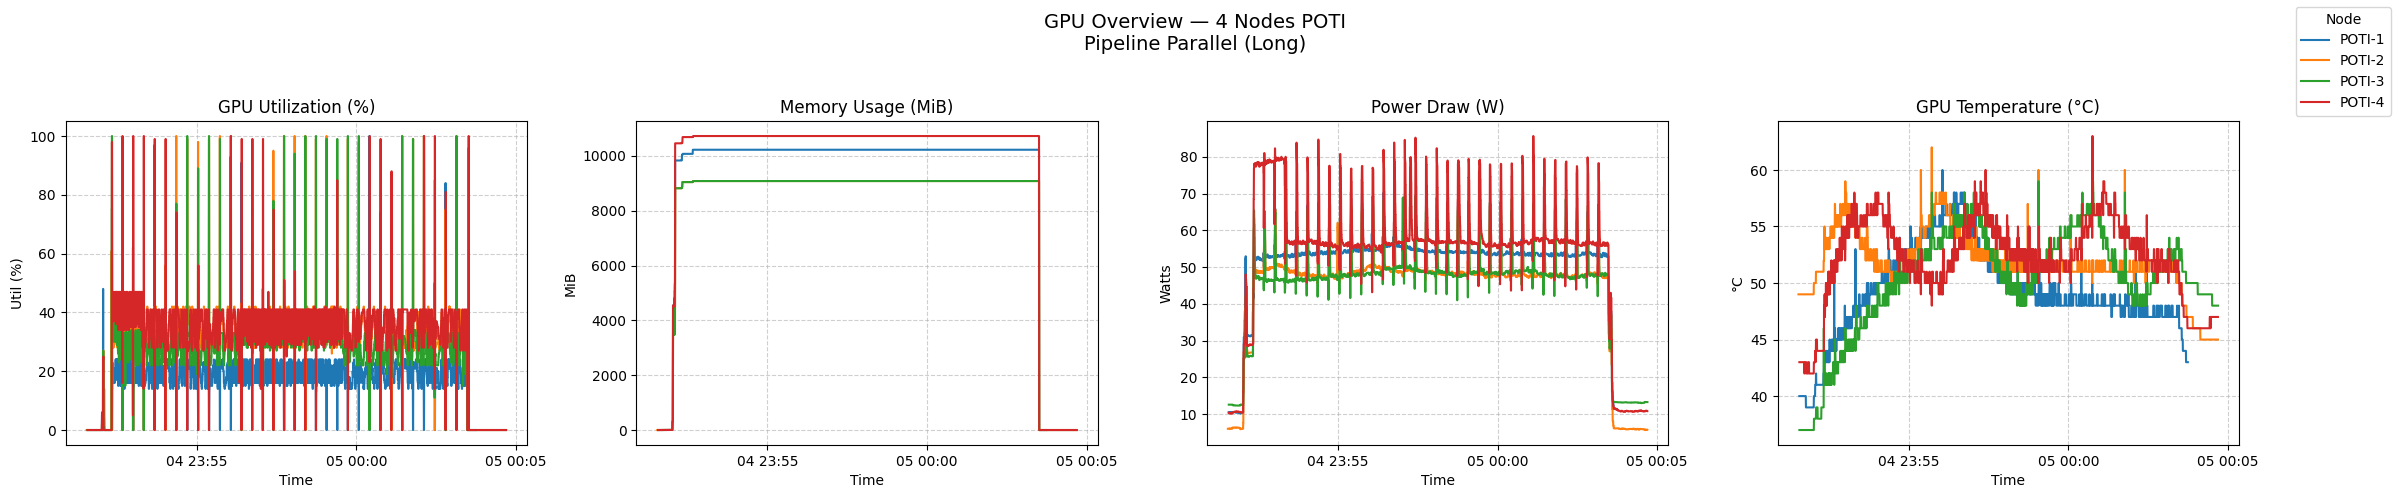

Saved: ../figures/gpu_telemetry/gpu-overview-N4-poti-PP-long-r1-780638.png


In [3]:
def plot_gpu_overview(experiment_name, exp_df):
    pretty_name = format_experiment_name(experiment_name)

    if exp_df.empty:
        print(f"No telemetry for {experiment_name}")
        return

    fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharex=True)
    ax_util, ax_mem, ax_power, ax_temp = axes

    series = {
        'gpu_utilization': ax_util,
        'memory_used_mib': ax_mem,
        'power_draw_w': ax_power,
        'temperature_gpu_c': ax_temp,
    }

    for node_name, node_df in exp_df.groupby('node_name'):
        node_df = node_df.sort_values('timestamp')
        node_label = format_node_name(node_name)

        for col, ax in series.items():
            if col in node_df.columns:
                ax.plot(node_df['timestamp'], node_df[col], label=node_label)

    ax_util.set_title('GPU Utilization (%)')
    ax_mem.set_title('Memory Usage (MiB)')
    ax_power.set_title('Power Draw (W)')
    ax_temp.set_title('GPU Temperature (°C)')

    ax_util.set_ylabel('Util (%)')
    ax_mem.set_ylabel('MiB')
    ax_power.set_ylabel('Watts')
    ax_temp.set_ylabel('°C')

    for ax in axes:
        ax.set_xlabel('Time')
        ax.grid(True, linestyle='--', alpha=0.6)

    handles, labels = ax_util.get_legend_handles_labels()
    fig.legend(handles, labels, title='Node', loc='upper right')
    fig.suptitle(f'GPU Overview — {pretty_name}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])

    filepath = FIGURES_DIR / f"gpu-overview-{experiment_name.replace('_', '-')}.png"
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filepath}")


for experiment_name in sorted(experiment_names, key=sort_experiments):
    exp_df = ts_df[ts_df['experiment_name'] == experiment_name]
    plot_gpu_overview(experiment_name, exp_df)